full-agent 完整代理 -----系统架构图

               用户问题
                            │
                            ▼
                  ┌──────────────────┐
                  │    Parent Agent  │
                  │   create_agent   │
                  └────────┬─────────┘
                           │
             ┌─────────────┼──────────────┐
             │             │              │
             ▼             ▼              ▼
        Todo工具        搜索工具        task工具
             │             │              │
             │             │              ▼
             │             │        subagent_type
             │             │              │
             │             │              ▼
             │             │      ┌───────────────┐
             │             │      │ research_agent│
             │             │      │create_react_  │
             │             │      │agent          │
             │             │      └───────┬───────┘
             │             │              │
             │             │        ┌─────┴─────┐
             │             │        ▼           ▼
             │             │   tavily_search think_tool
             │             │        │
             │             │        ▼
             │             │      files
             │             │
             └─────────────┴────────┬───────────┘
                                    │
                                    ▼
                            DeepAgentState
                           ┌─────────────────┐
                           │ messages        │
                           │ todos           │
                           │ files           │
                           │ remaining_steps │
                           └─────────────────┘

In [36]:
from datetime import datetime
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.tools import InjectedToolCallId, InjectedToolArg, tool, BaseTool
from langgraph.prebuilt import InjectedState
from deep_agent_from_search.prompt import SUMMARIZE_WEB_SEARCH
from pydantic import BaseModel, Field
from tavily import TavilyClient
from typing_extensions import Annotated, Literal, TypedDict, NotRequired
from langchain.agents import AgentState
from Config.load_key import base_model, base_url, open_key

"""
构建状态
"""


class Todo(TypedDict):
    content: str


def file_reducer(left, right):
    if left is None:
        return right
    if right is None:
        return left
    return {**left, **right}


class DeepAgentState(AgentState):
    todos: NotRequired[list[Todo]]
    files: NotRequired[Annotated[dict[str, str], file_reducer]]
    remaining_steps: NotRequired[int]


# 大模型初始化
summarization_model = ChatOpenAI(
    model=base_model,
    base_url=base_url,
    api_key=open_key
)
#搜索引擎初始化
tavily_client = TavilyClient(
    api_key=""
)

In [37]:
import httpx
from markdownify import markdownify
from langchain_core.messages import HumanMessage, ToolMessage


class Summary(BaseModel):
    """网页内容摘要"""
    filename: str = Field(description="文件存储的名称")
    summary: str = Field(description="网页的关键信息")


def get_today_str() -> str:
    """获取当前日期时间"""
    return datetime.today().strftime('%Y-%m-%d')


def run_tavily_search(
        search_query: str,
        max_results: int,
        topic: Literal["general", "news", "finance"] = "general",
        include_raw_content: bool = True,
):
    """
    使用Tavily Api对单个查询执行搜索
    Args:
        search_query:要执行的搜索查询
        max_results:每次查询的最大结果数量
        topic:搜索结果的主题过滤属性
        include_raw_content:是否包含原始网页内容
    Returns:
        搜索结果字典
    """
    result = tavily_client.search(
        query=search_query,
        max_results=max_results,
        topic=topic,
        include_raw_content=include_raw_content,
    )
    return result


def summarize_webpage_content(webpage_content) -> Summary:
    """
    使用配置的摘要模型对网页内容进行总结
    Args:
        webpage_content:要总结的原始网页内容
    Returns:
        包含五年级名和摘要的摘要对象
    """
    try:
        #设置用于摘要的结构化输出模型
        structured_model = summarization_model.with_structured_output(Summary)

        #生成摘要
        summary_and_filename = structured_model.invoke(
            [
                HumanMessage(
                    content=SUMMARIZE_WEB_SEARCH.format(
                        webpage_content=webpage_content,
                        date=get_today_str(),
                    )
                )
            ]
        )
        return summary_and_filename
    except Exception:
        return Summary(
            filename='search_result.md',
            summary=webpage_content[:1000] + '...' if len(webpage_content) > 1000 else webpage_content,
        )


def process_search_result(results: dict) -> list[dict]:
    """
    通过对可用内容中进行摘要来处理搜索结果
    Args:
        results:Tavily搜索结果字典
    Returns:
        包含摘要的处理结果列表
    """
    processed_results = []
    HTTPX_CLIENT = httpx.Client()
    for i, result in enumerate(results.get("results", [])):  # 加 enumerate 拿到索引
        url = result["url"]
        try:
            response = HTTPX_CLIENT.get(url, timeout=10)  # 加 timeout 防止卡死
            if response.status_code == 200:
                raw_content = markdownify(response.text)
                summary_obj = summarize_webpage_content(raw_content)
            else:
                raw_content = result.get("raw_content", "")
                # ✅ 修复：给一个有效的默认文件名，而不是 None
                summary_obj = Summary(
                    filename=f'search_result_{i + 1}.md',
                    summary=result.get("content", "Error:错误"),
                )
        except Exception as e:
            # ✅ 增加异常处理，防止请求完全失败导致整个工具报错
            raw_content = result.get("raw_content", "")
            summary_obj = Summary(
                filename=f'search_result_{i + 1}.md',
                summary=result.get("content", f"Error: {str(e)}"),
            )

        # ✅ 确保文件名唯一，防止重名覆盖
        filename = summary_obj.filename
        if not filename or filename == 'search_result.md':
            filename = f'search_result_{i + 1}.md'

        processed_results.append({
            "url": result["url"],
            "title": result["title"],
            "summary": summary_obj.summary,
            "filename": filename,
            "raw_content": raw_content,
        })
    return processed_results


@tool(parse_docstring=True)
def tavily_search(
        query: str,
        state: Annotated[DeepAgentState, InjectedState],
        tool_call_id: Annotated[str, InjectedToolCallId],
        max_results: Annotated[int, InjectedToolArg] = 1,
        topic: Annotated[Literal["general", "news", "finance"], InjectedToolArg] = "general",
):
    """
    搜索网络并将详细结果保存到文件中，同时返回最少的上下文
    执行网络搜索并将完整内容保存到文件中，用于上下文卸载
    仅返回关键信息，以帮助代理决定下一步行动

    Args:
        query:要执行的搜索查询
        state:注入的代理状态用于文件存储
        tool_call_id:注入的工具调用标识符
        max_results:返回结果的最大数量（默认值：1）
        topic:主题过滤器-"general", "news", "finance"“，默认general

    Returns:
        将完整结果保存到文件并提供最小的摘要命令
    """
    search_result = run_tavily_search(
        query,
        max_results=max_results,
        topic=topic,
        include_raw_content=True,
    )
    # 处理并汇总结果
    processed_results = process_search_result(search_result)
    # 将每个结构保存到文件并准备摘要
    files = state.get('files', {})
    saved_files = []
    summaries = []
    for i, result in enumerate(processed_results):
        filename = result['filename']
        file_content = f"""
            Search Result:{result['title']}
            **URL**: {result['url']}
            **Query**: {query}
            **Date**: {get_today_str()}
            # Summary:
            {result['summary']}
            # Raw Content:
            {result['raw_content'] if result['raw_content'] else ''}
        """
        files[filename] = file_content
        saved_files.append(filename)
        summaries.append(f"--{filename}: {result['summary']}...")

    summary_text = f"""
            搜索到{len(processed_results)}条数据：
            {chr(10).join(summaries)}
            Files:{','.join(saved_files)},当我们需要详细内容的时候可以调用read_file()
        """
    return Command(
        update={
            "files": files,
            "messages": [
                ToolMessage(
                    summary_text, tool_call_id=tool_call_id
                )
            ]
        }
    )


@tool(parse_docstring=True)
def think_tool(reflection: str) -> str:
    """
    用于对研究进展和决策进行战略反思的工具
    每次搜索后使用此工具，系统地分析结果并规划下一步
    这在研究工作流程中创造了一个有意识的暂停，以实现高质量决策
    何时使用：
    -收到搜索结果后：我发现了哪些关键信息？
    =决定下一步之前：我是否拥有足够信息来全面回答？
    -在评估研究空白时：我仍缺少哪些具体信息？
    -在得出结论之前：我现在能提供一个完整的答案嘛？
    反思：
    1、当前发现的分析--我收集了哪些具体信息？
    2、缺陷评估--还缺少哪些关键信息
    3、质量评估--我是否有足够的证据/例子来提供一个良好的答案？
    4、战略决策--我是否应继续搜索或给出的答案？

    Args:
        reflection:您对研究进展、发现、空白点及下一步行动的详细反思

    Returns:
        确认反思已记录用于决策制定
    """
    return f"记录{reflection}"

In [38]:
from deep_agent_from_search.prompt import LS_DESCRIPTION, READ_FILE_DESCRIPTION, WRITE_FILE_DESCRIPTION
from langgraph.prebuilt import InjectedState
from langchain.tools import InjectedToolCallId
from langgraph.types import Command
from langchain.messages import ToolMessage


@tool(description=LS_DESCRIPTION)
def ls(state: Annotated[DeepAgentState, InjectedState]):
    return list(state.get('files', {}).keys())


@tool(description=READ_FILE_DESCRIPTION)
def read_file(file_path: str, state: Annotated[dict, InjectedState], offset: int = 0, limit: int = 2000):
    files = state.get('files', {})
    if file_path not in files:
        return f"Error:文件{file_path}不存在！"
    content = files[file_path]
    if not content:
        return "System reminder：文件存在但是内容为空！"

    lines = content.splitlines()  #将内容按分割成list
    start_index = offset  #开始行数
    end_index = min(start_index + limit, len(lines))  #结尾行数，最大不能超过总行数

    if start_index >= len(lines):
        return f"Error:偏移量{offset}大于行总数"

    result_lines = []
    for i in range(start_index, end_index):
        line_content = lines[i][:2000]  #获取当前行，最多2000个字符
        result_lines.append(f"{i + 1:6d} \t{line_content}")

    return "\n".join(result_lines)


@tool(description=WRITE_FILE_DESCRIPTION)
def write_file(file_path: str, content: str, state: Annotated[dict, InjectedState],
               tool_call_id: Annotated[str, InjectedToolCallId]):
    files = state.get('files', {})
    files[file_path] = content
    return Command(
        update={
            "files": files,
            "messages": [
                ToolMessage(
                    f"更新文件信息{file_path}", tool_call_id=tool_call_id
                )
            ]
        }
    )


from deep_agent_from_search.prompt import TASK_DESCRIPTION_PREFIX
from langgraph.prebuilt import create_react_agent


class SubAgent(TypedDict):
    """专业子代理的配置"""
    name: str
    description: str
    prompt: str
    tools: NotRequired[list[str]]


def _create_task_tool(tools, subagents: list[SubAgent], model, state_schema):
    agents = {}
    tools_by_name = {}

    # 1. 整理工具
    for tool_ in tools:
        if not isinstance(tool_, BaseTool):
            tool_ = tool(tool_)
        tools_by_name[tool_.name] = tool_

    # 2. 创建子 Agent
    for _agent in subagents:
        if "tools" in _agent:
            _tools = [tools_by_name[name] for name in _agent["tools"]]
        else:
            _tools = tools

        agents[_agent["name"]] = create_react_agent(
            model=model,
            prompt=_agent["prompt"],
            tools=_tools,
            state_schema=state_schema,
        )
    other_agents_string = [
        f"- {_agent['name']}: {_agent['description']}"
        for _agent in subagents
    ]

    # 3. 创建 task 工具
    @tool(
        description=TASK_DESCRIPTION_PREFIX.format(
            other_agents=other_agents_string
        )
    )
    def task(
            description: str,
            subagent_type: str,
            state: Annotated[DeepAgentState, InjectedState],
            tool_call_id: Annotated[str, InjectedToolCallId],
    ):
        # 4. 判断子 Agent 是否存在
        if subagent_type not in agents:
            return f""" Error: 调用的代理类型为 {subagent_type} 允许的代理类型为 {list(agents.keys())} """

        sub_agent = agents[subagent_type]

        try:
            # 5. 给子 Agent 创建独立 State
            sub_state = {
                **state,
                "messages": [
                    {
                        "role": "user",
                        "content": description,
                    }
                ],
            }

            # 6. 真正调用子 Agent
            result = sub_agent.invoke(sub_state)

            # 7. 获取子 Agent 最终答案
            final_message = result["messages"][-1]
            # 8. 返回给父 Agent
            return Command(
                update={
                    "files": result.get("files", {}),
                    "messages": [
                        ToolMessage(
                            content=final_message.content,
                            tool_call_id=tool_call_id,
                        )
                    ],
                }
            )

        except Exception as e:
            import traceback

            traceback.print_exc()

            raise

    return task


from deep_agent_from_search.prompt import WRITE_TODOS_DESCRIPTION


@tool(description=WRITE_TODOS_DESCRIPTION)
def write_todos(
        todos: list[Todo],
        tool_call_id: Annotated[str, InjectedToolCallId]
) -> Command:
    """
    创建或更新代理的代办事项列表，用于任务规划和跟踪
    """
    return Command(
        update={
            "todos": todos,
            "messages": [
                ToolMessage(
                    f"更新任务清单:{todos}", tool_call_id=tool_call_id
                )
            ]
        }
    )


@tool(description="列出当前任务清单", parse_docstring=True)
def read_todos(
        state: Annotated[DeepAgentState, InjectedState]
) -> str:
    """
    从代理状态中读取当前的待办事项列表。

    Args:
        state: 包含当前 todo 列表的注入代理状态。

    Returns:
        当前 todo 列表的格式化字符串表示。
    """
    todos = state.get("todos", [])

    if not todos:
        return "当前没有任务清单"

    result = "任务列表：\n"

    for i, todo in enumerate(todos, 1):
        status_emoji = {
            "pending": "⏳",
            "in_progress": "🔄",
            "completed": "✅",
        }

        emoji = status_emoji.get(todo.get("status", ""), "" "?")

        result += (
            f"{i},{emoji}{todo['content']},({todo.get("status", "")})\n"
        )

    return result.strip()

In [43]:
from deep_agent_from_search.prompt import FILE_USAGE_INSTRUCTIONS, RESEARCHER_INSTRUCTIONS, SUBAGENT_USAGE_INSTRUCTIONS, \
    TODO_USAGE_INSTRUCTIONS

model = ChatOpenAI(
    base_url=base_url,
    api_key=open_key,
    model=base_model,
)
max_concurrent_research_units = 3
max_researcher_iterations = 3
sub_agent_tools = [tavily_search, think_tool]
build_in_tools = [ls, write_file, read_file, think_tool, write_todos, read_todos]

research_sub_agent = {
    "name": "research_agent",
    "description": "将研究任务委托给子代理的研究员。每次只给这位研究员一个研究主题",
    "prompt": RESEARCHER_INSTRUCTIONS,
    "tools": ["tavily_search", "think_tool"],
}
task_tool = _create_task_tool(
    sub_agent_tools, [research_sub_agent], model, DeepAgentState
)
print(task_tool)
delegation_tools = [task_tool]
all_tools = sub_agent_tools + build_in_tools + delegation_tools

SUBAGENT_INSTRUCTIONS = SUBAGENT_USAGE_INSTRUCTIONS.format(
    max_concurrent_research_units=max_concurrent_research_units,
    max_researcher_iterations=max_researcher_iterations,
    date=datetime.now().strftime("%Y%m%d%H%M%S")
)

INSTRUCTIONS = (
        '#TODO MANAGEMENT \n'
        + TODO_USAGE_INSTRUCTIONS
        + '\n\n'
        + '=' * 80
        + "\n\n"
        + "#FILE SYSTEM USAGE \n"
        + FILE_USAGE_INSTRUCTIONS
        + '\n\n'
        + '=' * 80
        + "\n\n"
        + '#SUB-AGENT \n'
        + SUBAGENT_INSTRUCTIONS
)

name='task' description="将任务委托给具有隔离上下文的专用子代理，可用于的代理有:\n['- research_agent: 将研究任务委托给子代理的研究员。每次只给这位研究员一个研究主题']" args_schema=<class 'langchain_core.utils.pydantic.task'> func=<function _create_task_tool.<locals>.task at 0x000001D83A1DA840>


C:\Users\TaoYu\AppData\Local\Temp\ipykernel_39424\2880114072.py:83: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agents[_agent["name"]] = create_react_agent(


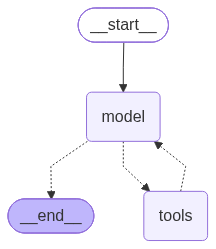

In [40]:
from langchain.agents import create_agent
from IPython.display import display, Image

agent = create_agent(
    model=model,
    system_prompt=INSTRUCTIONS,
    state_schema=DeepAgentState,
    tools=all_tools,
)
display(Image(agent.get_graph().draw_mermaid_png()))

In [41]:
from utils import print_stream_chunk

result = agent.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "帮我研究 LangGraph 和 Deep Agents 的区别"
            }
        ],
        "files": {}
    }
)
for chunk in result:
    print('===' * 40)
    print_stream_chunk(chunk)


📌 节点：model
🔧 调用工具：ls
   参数：{}

📌 节点：tools
🔨 工具结果：ls
   []

📌 节点：model
🔧 调用工具：write_file
   参数：{'file_path': 'user_request.md', 'content': '帮我研究 LangGraph 和 Deep Agents 的区别'}

📌 节点：tools
🔨 工具结果：write_file
   更新文件信息user_request.md

📌 节点：model
🔧 调用工具：write_todos
   参数：{'todos': [{'content': '将用户请求保存到文件系统中以供参考', 'status': 'completed'}, {'content': '研究 LangGraph 的核心概念、功能和应用场景', 'status': 'in_progress'}, {'content': '研究 Deep Agents 的核心概念、功能和应用场景', 'status': 'todo'}, {'content': '比较 LangGraph 和 Deep Agents 的区别并汇编综合回应', 'status': 'todo'}]}

📌 节点：tools
🔨 工具结果：write_todos
   更新任务清单:[{'content': '将用户请求保存到文件系统中以供参考'}, {'content': '研究 LangGraph 的核心概念、功能和应用场景'}, {'content': '研究 Deep Agents 的核心概念、功能和应用场景'}, {'content': '比较 LangGraph 和 Deep Agents 的区别并汇编综合回应'}]

📌 节点：model
🔧 调用工具：task
   参数：{'description': '研究 LangGraph 的核心概念、功能和应用场景，包括其在构建基于 LLM 的代理系统中的作用、主要特性、架构设计以及典型使用案例。请提供详细的技术说明和实际应用示例。', 'subagent_type': 'research_agent'}

📌 节点：tools
🔨 工具结果：task
   # LangGraph 核心概念、功能和应用场景详解

## 核心概念

LangGrap